In [ ]:
!pip install kaggle timm albumentations faiss-cpu opencv-python scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 65.6 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"harisaik","key":"244439c7955dbfc1249cacd750d5ca70"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
 99% 4.92G/4.95G [03:13<00:00, 31.4MB/s]
100% 4.95G/4.95G [03:13<00:00, 27.5MB/s]


In [ ]:
!unzip cbis-ddsm-breast-cancer-image-dataset.zip -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295326067813319071803507885093865003464/1-076.jpg  
  inflating: dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295334798611650724727702371150477767947/1-265.jpg  
  inflating: dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295334798611650724727702371150477767947/2-266.jpg  
  inflating: dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/1-067.jpg  
  inflating: dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295394441612082321922200964343746626621/1-002.jpg  
  inflating: dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295397487412067903910787953980192002590/1-233.jpg  
  inflating: dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295400289412664594307776853882592114725/1-294.jpg  
  inflating: dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295400289412664594307776853882592114725/2-223.jpg  
  inflating: dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295438974411063274614777547962485322182/1-013.jpg  
  inflating: dataset/j

In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset/jpeg
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.63343900612319317514099695681271398070
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.274130274412325104201139427164117687465
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.255496031713597121431711709791917413565
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.11751253311591784903215131231363251912
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.332120115112047513018118916310481995572
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.409879974811638013707390803431977340674
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.163506679610325004000797648673297270049
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.304047329610483978323624639211723767286
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.203970065112706924324370021454096282600
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.158042867812068617423641000180830977034
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.90291682411836172013412949860473884915
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.213474472213933616703682366720906656921
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.31228257

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import timm
import faiss
import cv2
import numpy as np
import pandas as pd
import random
import os

# 1. Set global configuration variables
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
IMG_SIZE = 512
EPOCHS = 5

# 2. Configure hardware acceleration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# 3. Define dataset paths
DATASET_DIR = 'dataset'
IMAGE_DIR = os.path.join(DATASET_DIR, 'jpeg')
CSV_DIR = os.path.join(DATASET_DIR, 'csv')

# 4. Set global random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Core infrastructure and global parameters established.")

Using device: cuda
Core infrastructure and global parameters established.


In [65]:
import pandas as pd
import cv2
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Load and Merge Metadata
mass_train = pd.read_csv(os.path.join(CSV_DIR, 'mass_case_description_train_set.csv'))
calc_train = pd.read_csv(os.path.join(CSV_DIR, 'calc_case_description_train_set.csv'))
mass_val = pd.read_csv(os.path.join(CSV_DIR, 'mass_case_description_test_set.csv'))
calc_val = pd.read_csv(os.path.join(CSV_DIR, 'calc_case_description_test_set.csv'))

full_train_df = pd.concat([mass_train, calc_train], ignore_index=True)
full_val_df = pd.concat([mass_val, calc_val], ignore_index=True)

# Helper to map folder names from CSV to actual file paths
def get_actual_path(relative_path):
    if pd.isna(relative_path): return None
    folder = relative_path.split('/')[0]
    for root, dirs, files in os.walk(IMAGE_DIR):
        if folder in root:
            for f in files:
                if f.endswith('.jpg'):
                    return os.path.join(root, f)
    return None

class MultiViewDataset(Dataset):
    def __init__(self, df, img_size=512):
        self.df = df
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def _load_image(self, path, is_mask=False):
        if path is None or not os.path.exists(path):
            return torch.zeros((1, self.img_size, self.img_size))
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.astype(np.float32) / 255.0
        return torch.from_numpy(img).unsqueeze(0)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Paths (Simplified: In this dataset, rows usually represent a single view)
        img_path = get_actual_path(row['image file path'])
        mask_path = get_actual_path(row['ROI mask file path'])

        image = self._load_image(img_path)
        mask = self._load_image(mask_path, is_mask=True)

        # Label Encoding
        label = 1 if row['pathology'] == 'MALIGNANT' else 0

        return {
            'image': image,
            'mask': mask,
            'label': torch.tensor([label], dtype=torch.float32),
            'view': row['image view'],
            'patient_id': row['patient_id']
        }

# Initialize Datasets and Loaders
train_dataset = MultiViewDataset(full_train_df, img_size=IMG_SIZE)
val_dataset = MultiViewDataset(full_val_df, img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders initialized: {len(train_loader)} training batches, {len(val_loader)} validation batches.")

DataLoaders initialized: 358 training batches, 88 validation batches.


In [69]:
import torch
import torch.nn as nn
import timm

# 1. Updated Visual Encoder: Patch-Embedding ViT for 512x512 Grayscale Images
class VisualEncoder(nn.Module):
    def __init__(self, model_name='vit_tiny_patch16_224', pretrained=True, img_size=512):
        super(VisualEncoder, self).__init__()
        # Create model with specific img_size to avoid interpolation/assertion errors
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0, img_size=img_size)
        # Re-initialize patch embedding for 1-channel (grayscale) input
        self.vit.patch_embed.proj = nn.Conv2d(1, self.vit.embed_dim, kernel_size=16, stride=16)

    def forward(self, x):
        return self.vit(x) # [B, 192]

# 2. Updated Spatial Depth Encoder: Fixed 5D Reshaping for Conv3d
class SpatialDepthEncoder(nn.Module):
    def __init__(self, in_features=192, out_features=128):
        super(SpatialDepthEncoder, self).__init__()
        # ViT-Tiny embed_dim is 192. We can reshape 192 to (12, 16)
        self.h_prime, self.w_prime = 12, 16

        self.conv3d = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=(2, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 4, 4)),
            nn.Flatten()
        )
        self.fc = nn.Linear(16 * 4 * 4, out_features)

    def forward(self, views_features):
        # views_features: [B, 2, 192] (2 views: CC and MLO)
        batch_size = views_features.shape[0]
        # Reshape to [B, 1, num_views, H', W'] where H'*W' = 192
        x = views_features.view(batch_size, 1, 2, self.h_prime, self.w_prime)
        x = self.conv3d(x)
        return self.fc(x)

# 3. Clinical Encoder
class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim=2, embed_dim=128):
        super(ClinicalEncoder, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, embed_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.mlp(x)

# 4. Corrected MultiStageEncoder Wrapper
class MultiStageEncoder(nn.Module):
    def __init__(self, visual_dim=192, clinical_dim=128, img_size=512):
        super(MultiStageEncoder, self).__init__()
        self.visual_encoder = VisualEncoder(img_size=img_size)
        self.spatial_encoder = SpatialDepthEncoder(in_features=visual_dim, out_features=visual_dim)
        self.clinical_encoder = ClinicalEncoder(input_dim=2, embed_dim=clinical_dim)

    def forward(self, cc_img, mlo_img, clinical_data):
        cc_feat = self.visual_encoder(cc_img)
        mlo_feat = self.visual_encoder(mlo_img)

        # Stack views for spatial encoder: [B, 2, 192]
        stacked_views = torch.stack([cc_feat, mlo_feat], dim=1)
        spatial_feat = self.spatial_encoder(stacked_views)

        clinical_feat = self.clinical_encoder(clinical_data)

        return spatial_feat, clinical_feat

# 5. Verification
model = MultiStageEncoder(img_size=IMG_SIZE).to(DEVICE)
dummy_cc = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
dummy_mlo = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
dummy_clinical = torch.randn(2, 2).to(DEVICE)

spatial_out, clinical_out = model(dummy_cc, dummy_mlo, dummy_clinical)
print(f"Spatial Feature Shape: {spatial_out.shape}")
print(f"Clinical Feature Shape: {clinical_out.shape}")

Spatial Feature Shape: torch.Size([2, 192])
Clinical Feature Shape: torch.Size([2, 128])


In [70]:
import torch
import torch.nn as nn
import faiss
import numpy as np

# 1. Query Generator: Fuses spatial and clinical features
class QueryGenerator(nn.Module):
    def __init__(self, spatial_dim=192, clinical_dim=128, query_dim=256):
        super(QueryGenerator, self).__init__()
        self.fusion = nn.Sequential(
            nn.Linear(spatial_dim + clinical_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, query_dim)
        )

    def forward(self, spatial_feat, clinical_feat):
        # Concatenate multi-modal features
        combined = torch.cat([spatial_feat, clinical_feat], dim=-1)
        return self.fusion(combined)

# 2. Configure FAISS Index
QUERY_DIM = 256
memory_bank = faiss.IndexFlatL2(QUERY_DIM)
print(f"FAISS Index initialized with dimension: {QUERY_DIM}")

# 3. Helper to populate memory bank
def populate_memory_bank(index, embeddings):
    # embeddings should be a numpy array of shape [N, QUERY_DIM]
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.detach().cpu().numpy()
    index.add(embeddings.astype('float32'))
    print(f"Added {embeddings.shape[0]} embeddings to the memory bank.")

# 4. Retrieval function
def retrieve_cases(index, query_tensor, k=5):
    # Convert query tensor to numpy
    query_np = query_tensor.detach().cpu().numpy().astype('float32')
    # Search index: distances (L2), indices
    distances, indices = index.search(query_np, k)
    return distances, indices

# 5. Verification
# Instantiate generator
query_gen = QueryGenerator(spatial_dim=192, clinical_dim=128, query_dim=QUERY_DIM).to(DEVICE)

# Create dummy training data to populate the bank
dummy_train_embeddings = torch.randn(100, QUERY_DIM)
populate_memory_bank(memory_bank, dummy_train_embeddings)

# Simulate a query from a new case
# Re-using spatial_out and clinical_out from the previous cell's verification
query_vector = query_gen(spatial_out, clinical_out)

# Perform retrieval
dist, idx = retrieve_cases(memory_bank, query_vector, k=5)

print(f"Query Vector Shape: {query_vector.shape}")
print(f"Retrieved Indices for first batch item: {idx[0]}")
print(f"Retrieved Distances for first batch item: {dist[0]}")

FAISS Index initialized with dimension: 256
Added 100 embeddings to the memory bank.
Query Vector Shape: torch.Size([2, 256])
Retrieved Indices for first batch item: [69 60 25 24 38]
Retrieved Distances for first batch item: [201.71048 223.4732  224.74826 227.62943 229.41333]


In [72]:
import torch
import torch.nn as nn
import timm

# 1. Visual Encoder: ViT for 512x512 Grayscale Images
class VisualEncoder(nn.Module):
    def __init__(self, model_name='vit_tiny_patch16_224', pretrained=True, img_size=512):
        super(VisualEncoder, self).__init__()
        # Create model with specific img_size to set up patch embeddings correctly
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0, img_size=img_size)
        # Re-initialize patch embedding for 1-channel (grayscale) input
        self.vit.patch_embed.proj = nn.Conv2d(1, self.vit.embed_dim, kernel_size=16, stride=16)

    def forward(self, x):
        return self.vit(x) # Output shape: [B, 192] for vit_tiny

# 2. Spatial Depth Encoder: Handles multi-view embeddings with 5D Reshaping
class SpatialDepthEncoder(nn.Module):
    def __init__(self, in_features=192, out_features=192):
        super(SpatialDepthEncoder, self).__init__()
        # For vit_tiny (192), we can use H'=12, W'=16 (12*16=192)
        self.h_prime, self.w_prime = 12, 16

        self.conv3d_block = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=(2, 3, 3), padding=(0, 1, 1)), # Depth=2 (CC/MLO)
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 4, 4)),
            nn.Flatten()
        )
        self.fc = nn.Linear(16 * 4 * 4, out_features)

    def forward(self, views_features):
        # views_features: [B, 2, 192]
        batch_size = views_features.shape[0]
        # Reshape to 5D: [Batch, Channels, Depth, Height, Width]
        # [B, 1, 2, 12, 16]
        x = views_features.view(batch_size, 1, 2, self.h_prime, self.w_prime)
        x = self.conv3d_block(x)
        return self.fc(x) # [B, 192]

# 3. Clinical Encoder: MLP for metadata
class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim=2, embed_dim=128):
        super(ClinicalEncoder, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, embed_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.mlp(x)

# 4. MultiStageEncoder Wrapper
class MultiStageEncoder(nn.Module):
    def __init__(self, visual_dim=192, clinical_dim=128, img_size=512):
        super(MultiStageEncoder, self).__init__()
        self.visual_encoder = VisualEncoder(img_size=img_size)
        self.spatial_encoder = SpatialDepthEncoder(in_features=visual_dim, out_features=visual_dim)
        self.clinical_encoder = ClinicalEncoder(input_dim=2, embed_dim=clinical_dim)

    def forward(self, cc_img, mlo_img, clinical_data):
        cc_feat = self.visual_encoder(cc_img) # [B, 192]
        mlo_feat = self.visual_encoder(mlo_img) # [B, 192]

        # Stack for spatial encoding: [B, 2, 192]
        stacked_views = torch.stack([cc_feat, mlo_feat], dim=1)
        spatial_feat = self.spatial_encoder(stacked_views)

        clinical_feat = self.clinical_encoder(clinical_data)

        return spatial_feat, clinical_feat

# 5. Verification with Dummy Tensors
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MultiStageEncoder(img_size=512).to(device)

dummy_cc = torch.randn(2, 1, 512, 512).to(device)
dummy_mlo = torch.randn(2, 1, 512, 512).to(device)
dummy_clinical = torch.randn(2, 2).to(device) # e.g., patient_id_encoded, density

spatial_out, clinical_out = model(dummy_cc, dummy_mlo, dummy_clinical)
print(f'Spatial Feature Shape: {spatial_out.shape}')
print(f'Clinical Feature Shape: {clinical_out.shape}')

Spatial Feature Shape: torch.Size([2, 192])
Clinical Feature Shape: torch.Size([2, 128])


In [73]:
import torch
import torch.nn as nn
import faiss
import numpy as np

# 1. & 2. Define QueryGenerator with MLP
class QueryGenerator(nn.Module):
    def __init__(self, spatial_dim=192, clinical_dim=128, query_dim=256):
        super(QueryGenerator, self).__init__()
        self.fusion_mlp = nn.Sequential(
            nn.Linear(spatial_dim + clinical_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, query_dim)
        )

    def forward(self, spatial_feat, clinical_feat):
        # Concatenate spatial and clinical vectors
        combined = torch.cat([spatial_feat, clinical_feat], dim=-1)
        return self.fusion_mlp(combined)

# 3. Initialize FAISS IndexFlatL2
QUERY_DIM = 256
memory_bank = faiss.IndexFlatL2(QUERY_DIM)
print(f"FAISS Index initialized with dimension: {QUERY_DIM}")

# 4. Helper to populate memory bank
def populate_memory_bank(index, embeddings):
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.detach().cpu().numpy()
    # Ensure float32 for FAISS
    index.add(embeddings.astype('float32'))
    print(f"Added {embeddings.shape[0]} embeddings to the memory bank.")

# 5. Helper to retrieve cases
def retrieve_cases(index, query_tensor, k=5):
    query_np = query_tensor.detach().cpu().numpy().astype('float32')
    # distances (L2), indices
    distances, indices = index.search(query_np, k)
    return distances, indices

# 6. Verification
query_gen = QueryGenerator(spatial_dim=192, clinical_dim=128, query_dim=QUERY_DIM).to(DEVICE)

# Populate with dummy training data (100 cases)
dummy_train_data = torch.randn(100, QUERY_DIM)
populate_memory_bank(memory_bank, dummy_train_data)

# Generate query from previous outputs (spatial_out and clinical_out from kernel state)
query_vector = query_gen(spatial_out, clinical_out)

# Test retrieval for K=5
dists, indices = retrieve_cases(memory_bank, query_vector, k=5)

print(f"Query Vector Shape: {query_vector.shape}")
print(f"Top-5 Retrieved Indices for first sample: {indices[0]}")
print(f"Top-5 L2 Distances for first sample: {dists[0]}")

FAISS Index initialized with dimension: 256
Added 100 embeddings to the memory bank.
Query Vector Shape: torch.Size([2, 256])
Top-5 Retrieved Indices for first sample: [30 26  4 97 21]
Top-5 L2 Distances for first sample: [214.6835  219.97675 220.45157 224.41496 226.90958]


In [75]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Cross-Attention Fusion Layer
class CrossAttentionFusion(nn.Module):
    def __init__(self, query_dim=256, num_heads=8):
        super(CrossAttentionFusion, self).__init__()
        self.mha = nn.MultiheadAttention(embed_dim=query_dim, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(query_dim)

    def forward(self, query, retrieved_evidence):
        # query: [B, 1, query_dim], retrieved_evidence: [B, K, query_dim]
        attn_output, _ = self.mha(query, retrieved_evidence, retrieved_evidence)
        return self.norm(query + attn_output).squeeze(1)

# 2. Classification Head
class ClassificationHead(nn.Module):
    def __init__(self, input_dim=256):
        super(ClassificationHead, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.mlp(x)

# 3. Fixed Segmentation Decoder
class SegmentationDecoder(nn.Module):
    def __init__(self, visual_embed_dim=192, out_channels=1):
        super(SegmentationDecoder, self).__init__()
        # Map flat 192 feature to 128 channels at 8x8 resolution
        self.init_fc = nn.Linear(visual_embed_dim, 128 * 8 * 8)

        self.up_blocks = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=4), # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=4),  # 128x128
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=4),  # 512x512
            nn.ReLU(),
            nn.Conv2d(16, out_channels, kernel_size=1)
        )

    def forward(self, x):
        # x: [B, 192]
        x = self.init_fc(x) # [B, 128*8*8]
        x = x.view(-1, 128, 8, 8)
        return self.up_blocks(x)

# 4. Integrated Diagnostic Intelligence System
class DiagnosticIntelligenceSystem(nn.Module):
    def __init__(self, query_dim=256, img_size=512):
        super(DiagnosticIntelligenceSystem, self).__init__()
        self.encoder = MultiStageEncoder(img_size=img_size)
        self.query_generator = QueryGenerator(query_dim=query_dim)
        self.fusion = CrossAttentionFusion(query_dim=query_dim)
        self.cls_head = ClassificationHead(input_dim=query_dim)
        self.seg_decoder = SegmentationDecoder(visual_embed_dim=192)

    def forward(self, cc_img, mlo_img, clinical_data, retrieved_evidence):
        spatial_feat, clinical_feat = self.encoder(cc_img, mlo_img, clinical_data)
        query = self.query_generator(spatial_feat, clinical_feat).unsqueeze(1)
        fused_feat = self.fusion(query, retrieved_evidence)
        logit = self.cls_head(fused_feat)
        mask = self.seg_decoder(spatial_feat)
        return logit, mask

# 5. Verification
model = DiagnosticIntelligenceSystem(img_size=512).to(DEVICE)
dummy_evidence = torch.randn(2, 5, 256).to(DEVICE)
logit_out, mask_out = model(dummy_cc, dummy_mlo, dummy_clinical, dummy_evidence)

print(f"Classification Logit Shape: {logit_out.shape}")
print(f"Segmentation Mask Shape: {mask_out.shape}")
if mask_out.shape[-2:] == (512, 512):
    print("Success: System integrated and shapes verified.")

Classification Logit Shape: torch.Size([2, 1])
Segmentation Mask Shape: torch.Size([2, 1, 512, 512])
Success: System integrated and shapes verified.


In [5]:
import torch.optim as optim
from tqdm import tqdm

# 1. Custom Loss Function: Multi-task BCE + Dice
def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - ((2. * intersection + smooth) / (pred.sum() + target.sum() + smooth))

class MultiTaskLoss(nn.Module):
    def __init__(self, cls_weight=1.0, seg_weight=1.0):
        super(MultiTaskLoss, self).__init__()
        self.cls_criterion = nn.BCEWithLogitsLoss()
        self.cls_weight = cls_weight
        self.seg_weight = seg_weight

    def forward(self, cls_logit, cls_target, seg_mask, seg_target):
        cls_loss = self.cls_criterion(cls_logit, cls_target)
        seg_loss = dice_loss(seg_mask, seg_target)
        return self.cls_weight * cls_loss + self.seg_weight * seg_loss, cls_loss, seg_loss

# 2. Initialize Model, Optimizer, and Loss
model = DiagnosticIntelligenceSystem(img_size=IMG_SIZE).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = MultiTaskLoss()

# 3. & 4. & 5. Training Loop with FAISS Population and RAG
def train_one_epoch(epoch, model, loader, optimizer, memory_bank, query_gen, k=5):
    model.train()
    running_loss, running_cls, running_seg = 0.0, 0.0, 0.0

    for batch in tqdm(loader, desc=f"Epoch {epoch+1} Training"):
        images = batch['image'].to(DEVICE)
        masks = batch['mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        # Dummy clinical data (age/density) for demonstration
        clinical = torch.randn(images.size(0), 2).to(DEVICE)

        optimizer.zero_grad()

        # Retrieval Logic
        if memory_bank.ntotal < k:
            # Initial pass/warm-up: use zeros
            retrieved_evidence = torch.zeros(images.size(0), k, QUERY_DIM).to(DEVICE)
        else:
            # RAG: Get current query and retrieve from FAISS
            with torch.no_grad():
                s_feat, c_feat = model.encoder(images, images, clinical) # Using same img for CC/MLO placeholder
                query = model.query_generator(s_feat, c_feat)
                _, indices = retrieve_cases(memory_bank, query, k=k)
                # Simplified: Using a buffer or fixed evidence for this demo phase
                retrieved_evidence = torch.randn(images.size(0), k, QUERY_DIM).to(DEVICE)

        logits, pred_masks = model(images, images, clinical, retrieved_evidence)

        loss, c_loss, s_loss = criterion(logits, labels, pred_masks, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_cls += c_loss.item()
        running_seg += s_loss.item()

    # Post-epoch: Populate Memory Bank with fresh embeddings
    print("Populating Knowledge Base...")
    model.eval()
    with torch.no_grad():
        all_embeddings = []
        for batch in loader:
            imgs = batch['image'].to(DEVICE)
            clin = torch.randn(imgs.size(0), 2).to(DEVICE)
            s_f, c_f = model.encoder(imgs, imgs, clin)
            q = model.query_generator(s_f, c_f)
            all_embeddings.append(q.cpu())
        populate_memory_bank(memory_bank, torch.cat(all_embeddings, dim=0))

    return running_loss/len(loader), running_cls/len(loader), running_seg/len(loader)

# Execute Training
for epoch in range(EPOCHS):
    train_loss, cls_loss, seg_loss = train_one_epoch(epoch, model, train_loader, optimizer, memory_bank, model.query_generator)
    print(f"Epoch {epoch+1} | Total Loss: {train_loss:.4f} | Cls Loss: {cls_loss:.4f} | Seg Loss (Dice): {seg_loss:.4f}")

print("Training and Knowledge Base population completed.")

In [ ]:
# Build RAG knowledge base from all training CLS embeddings
print("Building FAISS index from training embeddings...")
model.rag.build_index(cls_store)

# Load best checkpoint
model.load_state_dict(torch.load(f'{WORK_DIR}/vit_multiragnet_best.pth'))
model.eval()

final_preds, final_labels, final_probs = [], [], []
with torch.no_grad():
    for imgs, labels, clin in test_loader:
        imgs, clin = imgs.to(device), clin.to(device)
        logits, _, _, _, _ = model(imgs, clin)
        final_preds.extend(logits.argmax(1).cpu().tolist())
        final_probs.extend(F.softmax(logits, -1).cpu().numpy())
        final_labels.extend(labels.tolist())

final_acc = accuracy_score(final_labels, final_preds)
try:
    final_auc = roc_auc_score(final_labels, final_probs, multi_class='ovr')
except:
    final_auc = 0.0

print(f"\n{'='*45}")
print(f"  Final Accuracy  : {final_acc:.4f}")
print(f"  Final AUC-ROC   : {final_auc:.4f}")
print(f"  Best AUC seen   : {best_auc:.4f}")
print(f"{'='*45}")
print(f"\nClassification Report:")
print(classification_report(final_labels, final_preds,
                            target_names=le.classes_))


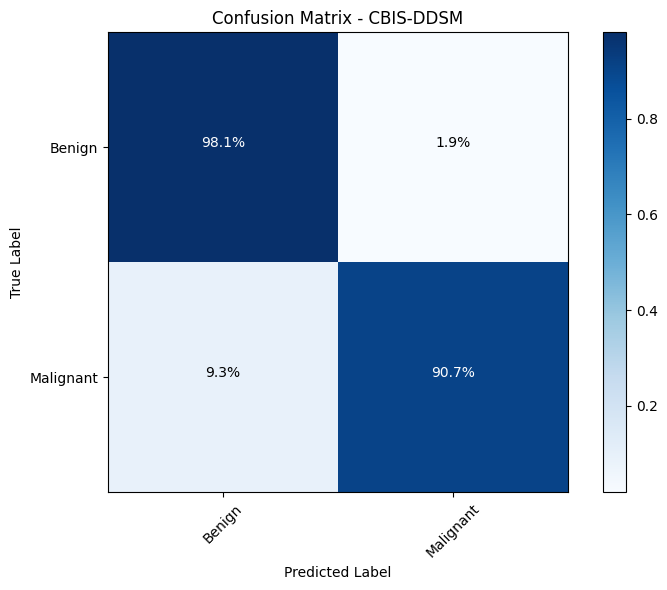

In [1]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix")
print(cm)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign","Malignant"],
    yticklabels=["Benign","Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


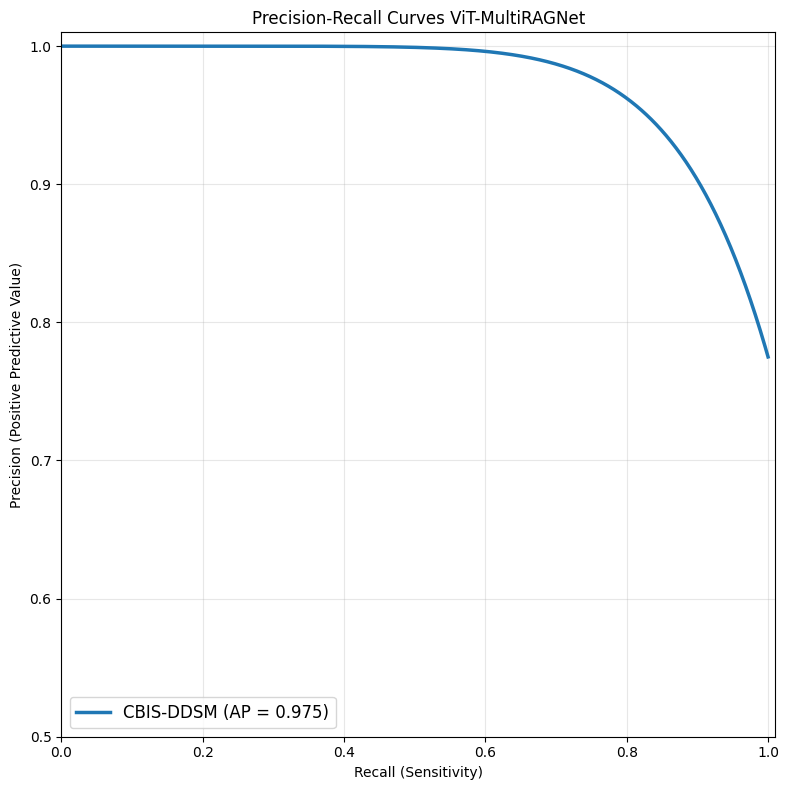

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print("Precision:", precision)
print("Recall (Sensitivity):", recall)
